In [17]:
from pathlib import Path
import matplotlib.pyplot as plt
import sys

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [6]:
import pandas as pd
from src.features import compute_daily_returns, get_close_prices

In [23]:
data = pd.read_parquet("/Users/wuyiwen/hk/data/raw/prices.parquet")
data.shape

(119, 50)

In [12]:
close_prices = get_close_prices(data)
close_prices.head()

,0939.HK,1088.HK,2628.HK,0941.HK,1288.HK,0883.HK,0857.HK,1398.HK,3988.HK,0700.HK
Date,,,,,,,,,,
2026-01-02,7.603889,38.488586,28.098551,80.968651,5.686519,21.389618,8.268428,6.164671,4.423877,615.825073
2026-01-05,7.477157,37.751038,29.053354,79.852852,5.501194,20.685108,7.977286,6.038267,4.355516,617.307800
2026-01-06,7.535648,38.566227,30.300447,79.755821,5.423163,20.841665,8.016105,6.038267,4.345750,625.215637
2026-01-07,7.428414,38.721500,31.001936,78.979614,5.364640,20.215439,7.783192,5.970202,4.345750,617.307800
2026-01-08,7.418666,39.711369,30.339418,78.542992,5.393902,20.235008,7.734668,5.931308,4.316453,608.905701


In [13]:
pair = ["0939.HK", "1398.HK"]
pair_prices = close_prices[pair].dropna(how="any")
pair_prices.head()

,0939.HK,1398.HK
Date,,
2026-01-02,7.603889,6.164671
2026-01-05,7.477157,6.038267
2026-01-06,7.535648,6.038267
2026-01-07,7.428414,5.970202
2026-01-08,7.418666,5.931308


<Axes: title={'center': 'Normalized Prices'}, xlabel='Date'>

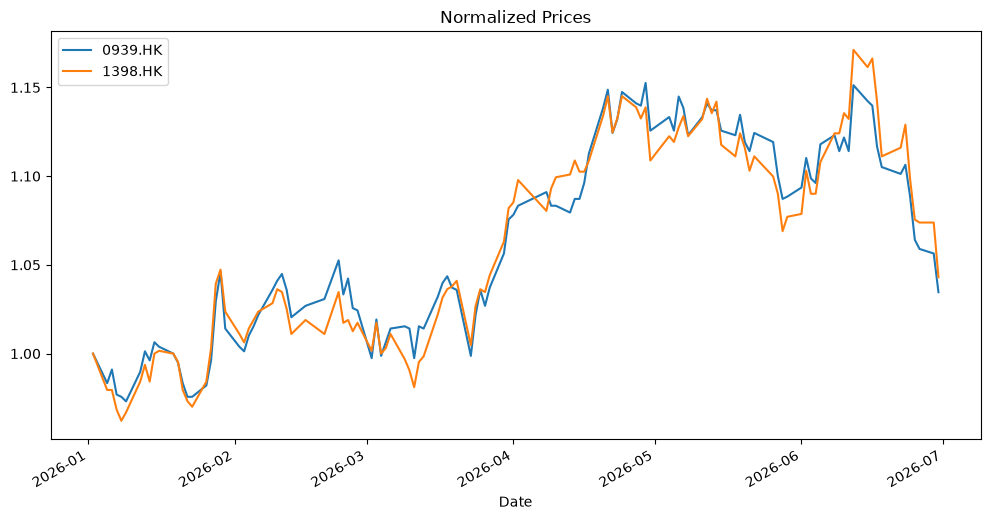

In [15]:
normalized = pair_prices / pair_prices.iloc[0]
normalized.plot(figsize=(12, 6), title="Normalized Prices")

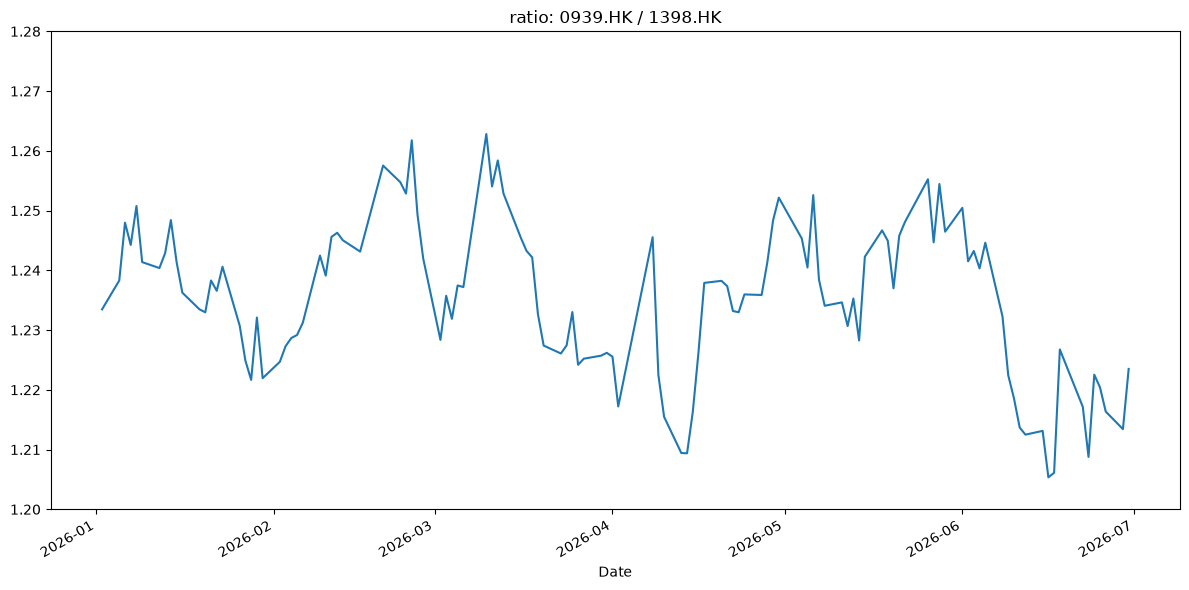

In [22]:
ratio = pair_prices["0939.HK"] / pair_prices["1398.HK"]
ratio_chart = ratio.plot(figsize=(12, 6), title="ratio: 0939.HK / 1398.HK")
ratio_chart.set_ybound(1.2, 1.28)
plt.tight_layout()
plt.show()

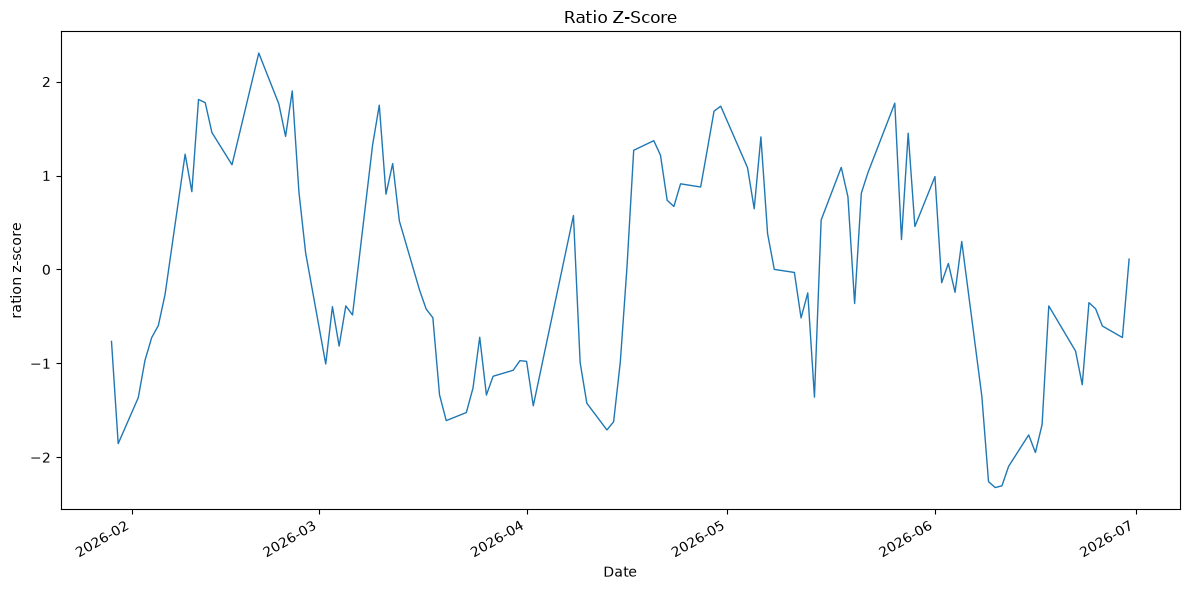

In [26]:
rolling_mean = ratio.rolling(window=20).mean()
rolling_std = ratio.rolling(window=20).std()
z_score = (ratio - rolling_mean) / rolling_std
z_score_chart = z_score.plot(figsize=(12, 6), title="Ratio Z-Score", linewidth=1)
z_score_chart.set_ylabel("ration z-score")
plt.tight_layout()
plt.show()

In [28]:
z_score.tail()

Date
2026-06-24   -0.353259
2026-06-25   -0.419501
2026-06-26   -0.601993
2026-06-29   -0.725028
2026-06-30    0.110653
dtype: float64